Dataset Shape: (27901, 18)

Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

First 5 rows:
    id  Gender  Age           City Profession  Academic Pressure  \
0   2    Male   33  Visakhapatnam    Student                  5   
1   8  Female   24      Bangalore    Student                  2   
2  26    Male   31       Srinagar    Student                  3   
3  30  Female   28       Varanasi    Student                  3   
4  32  Female   25         Jaipur    Student                  4   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0              0  8.97                   2                 0   
1              0  5.90                   5                 0   
2              0  7.03                   

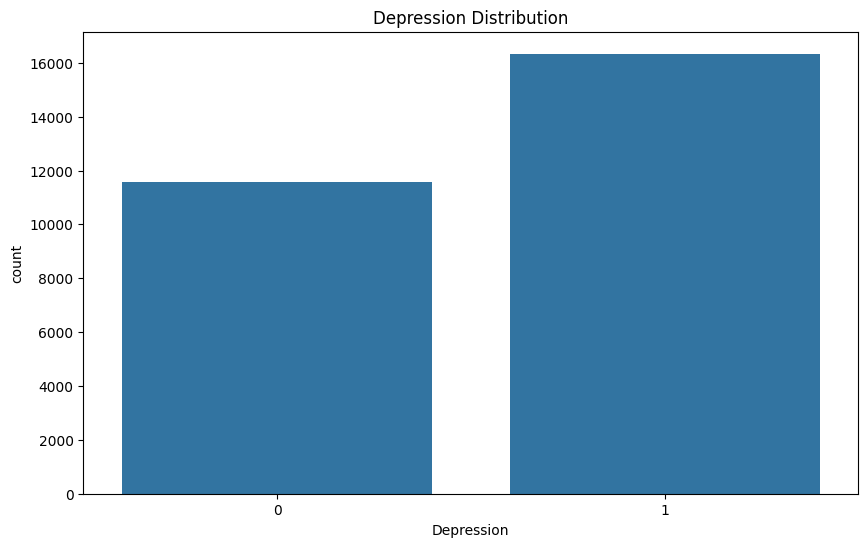

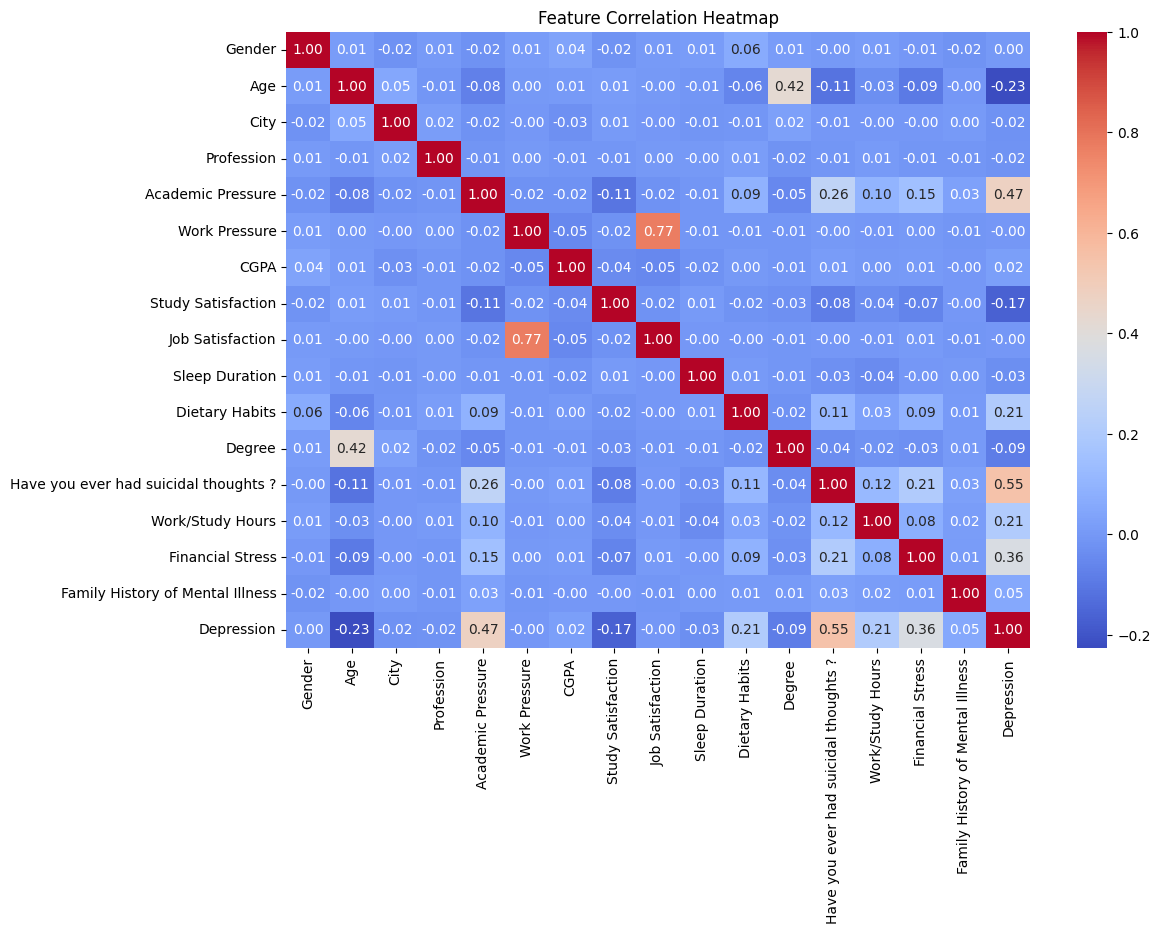


Visualizations saved: depression_distribution.png and correlation_heatmap.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("D:\Early Warning System for Academic Depression\student_depression_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['Depression'].value_counts() if 'Depression' in df.columns else "Target column not found")

if 'id' in df.columns or 'ID' in df.columns:
    df.drop(columns=['id', 'ID'], errors='ignore', inplace=True)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

target_col = 'Depression'
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

print("\nData after cleaning:")
print(df.info())

encoders = {}

categorical_features = [col for col in categorical_cols if col != target_col]

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"Encoded {col} - Classes: {le.classes_}")

# Save encoders
joblib.dump(encoders, 'categorical_encoders.pkl')

X = df.drop(columns=[target_col])
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

best_k = 5
best_acc = 0

for k in range(3, 21, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"\nBest K: {best_k} with Accuracy: {best_acc:.4f}")

# Final model
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

joblib.dump(model, 'knn_depression_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

plt.figure(figsize=(10, 6))
sns.countplot(x='Depression', data=df_original if 'df_original' in locals() else df)  # Use original for labels if needed
plt.title('Depression Distribution')
plt.savefig('depression_distribution.png')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

print("\nVisualizations saved: depression_distribution.png and correlation_heatmap.png")


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

def predict_depression(new_data_dict):
    model = joblib.load('knn_depression_model.pkl')
    scaler = joblib.load('feature_scaler.pkl')
    encoders = joblib.load('categorical_encoders.pkl')
    
    new_df = pd.DataFrame([new_data_dict])
    
    for col in encoders:
        if col in new_df.columns:
            value = str(new_df[col].iloc[0]).strip()  
            
            encoder = encoders[col]
            
            if value in encoder.classes_:
                new_df[col] = encoder.transform([value])[0]
            else:
                most_common = encoder.classes_[0]  
                print(f"Warning: Unseen category '{value}' in '{col}'. Mapping to '{most_common}' (most frequent).")
                new_df[col] = encoder.transform([most_common])[0]
    
    expected_cols = list(X.columns) if 'X' in globals() else list(scaler.feature_names_in_)
    for col in expected_cols:
        if col not in new_df.columns:
            new_df[col] = 0  
    
    new_df = new_df[expected_cols]
    
    new_scaled = scaler.transform(new_df)
    
    prediction = model.predict(new_scaled)[0]
    proba = model.predict_proba(new_scaled)[0].max()
    
    result = "High Risk of Depression (Yes)" if prediction == 1 else "Low Risk (No)"
    return {
        'prediction': result,
        'probability': f"{proba:.2%}",
        'risk_level': 'High' if prediction == 1 else 'Low'
    }

In [15]:
sample_input = {
    'Age': 22,
    'Gender': 'Female',
    'City': 'Mumbai',
    'Profession': 'Student',
    'Academic Pressure': 5.0,
    'Work Pressure': 5.0,
    'CGPA': 7.5,
    'Study Satisfaction': 3.0,
    'Job Satisfaction': 0.0,
    'Sleep Duration': '5-6 hours',         
    'Dietary Habits': 'Moderate',
    'Degree': 'B.Tech',
    'Have you ever had suicidal thoughts ?': 'Yes',
    'Work/Study Hours': 8.0,
    'Financial Stress': 5,
    'Family History of Mental Illness': 'No'
}

result = predict_depression(sample_input)
print("\nSample Prediction:", result)


Sample Prediction: {'prediction': 'High Risk of Depression (Yes)', 'probability': '89.47%', 'risk_level': 'High'}
